# Day 16 - NGBoost Hyperparameter Tuning

This notebook documents the Day 16 tuning pass for the weather forecast-error distribution model.

The target remains:

```text
forecast_error = actual_official_high - forecast_high
```

The goal was not to change model direction or build a benchmark zoo. The work tightened the existing NGBoost workflow with a compact, reproducible hyperparameter search using chronological validation and probability-quality metrics.


## What Changed Today

Day 16 added a reproducible tuning path around the existing NGBoost model:

- Added `config/model_config.yaml` with chronological split dates and a compact manual tuning grid.
- Added `python -m src.train_ngboost --mode tune`.
- Reused the existing feature list, target definition, chronological split utilities, bucket conversion layer, NLL helpers, coverage helpers, PIT, and calibration code.
- Kept the newest test period untouched during candidate selection.
- Logged every candidate to `outputs/ngboost_hyperparameter_search.csv`.
- Selected one v2 model using validation metrics only.
- Refit the selected hyperparameters on train + validation and saved `models/ngboost_best_v2.pkl`.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = REPO_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
MODELS = REPO_ROOT / "models"

search_path = OUTPUTS / "ngboost_hyperparameter_search.csv"
metadata_path = MODELS / "ngboost_best_v2_metadata.json"
notes_path = OUTPUTS / "best_ngboost_v2_notes.md"

search = pd.read_csv(search_path)
metadata = json.loads(metadata_path.read_text())

# The latest Day 16 run wrote seven grid rows. Keeping this slice makes the notebook
# robust if future tuning runs append to the same CSV.
latest_run = search.tail(7).copy()
selected_name = metadata["selected_candidate_name"]
selected = latest_run[latest_run["candidate_name"] == selected_name].iloc[0]

print(f"Loaded {len(latest_run)} latest tuning candidates from {search_path.relative_to(REPO_ROOT)}")
print(f"Selected candidate: {selected_name}")


Loaded 7 latest tuning candidates from outputs\ngboost_hyperparameter_search.csv
Selected candidate: more_trees_lower_lr


## Chronological Split

The split was chronological only:

- Train: oldest rows
- Validation: newer middle period
- Test: newest period

The test split was counted and preserved, but not used for tuning metrics or model selection.


In [2]:
split_rows = []
for split_name in ["train", "validation", "test"]:
    split = metadata["split_dates"]["splits"][split_name]
    split_rows.append({
        "split": split_name,
        "rows": split["row_count"],
        "start": split["date_min"],
        "end": split["date_max"],
    })

split_summary = pd.DataFrame(split_rows)
split_summary


,split,rows,start,end
0,train,17520,2022-01-01,2023-12-31
1,validation,8784,2024-01-01,2024-12-31
2,test,12120,2025-01-01,2026-05-20


In [3]:
display(Markdown(
    f"""
**Test set used during tuning:** `{metadata['test_set_used_for_tuning']}`  
**Refit selected model on train + validation:** `{metadata['refit_on_train_val']}`  
**Final training rows:** `{metadata['final_training_rows']:,}`
"""
))



**Test set used during tuning:** `False`  
**Refit selected model on train + validation:** `True`  
**Final training rows:** `26,304`


## Search Grid and Status

The grid intentionally stayed compact. It tested tree count, learning rate, depth, leaf regularization, and subsampling around the existing NGBoost setup.


In [4]:
grid_cols = [
    "candidate_name",
    "status",
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_samples_leaf",
    "minibatch_frac",
    "natural_gradient",
    "seed",
]
latest_run[grid_cols]


,candidate_name,status,n_estimators,learning_rate,max_depth,min_samples_leaf,minibatch_frac,natural_gradient,seed
0,v1_reference_or_near_reference,success,300,0.03,2,20,1.0,True,42
1,more_trees_lower_lr,success,500,0.02,2,20,1.0,True,42
2,many_trees_low_lr,success,700,0.01,2,20,1.0,True,42
3,slightly_deeper,success,500,0.02,3,20,1.0,True,42
4,deeper_more_regularized,success,700,0.01,3,30,1.0,True,42
5,shallow_large_leaf,success,500,0.02,2,50,1.0,True,42
6,shallow_subsampled,success,500,0.02,2,50,0.8,True,42


## Selection Metrics

Primary metric:

- Validation NLL / log score

Safeguard metrics:

- 50%, 80%, and 90% prediction interval coverage
- Bucket Brier score
- Interval log loss
- Calibration error
- PIT summary diagnostics

Point metrics were recorded only as secondary diagnostics:

- MAE
- RMSE
- Residual bias


In [5]:
metric_cols = [
    "candidate_name",
    "val_nll",
    "val_50_coverage",
    "val_80_coverage",
    "val_90_coverage",
    "val_bucket_brier",
    "val_interval_log_loss",
    "val_calibration_error",
    "val_mae",
    "val_rmse",
    "val_bias",
]
metrics_table = latest_run[metric_cols].copy().sort_values("val_nll")
metrics_table


,candidate_name,val_nll,val_50_coverage,val_80_coverage,val_90_coverage,val_bucket_brier,val_interval_log_loss,val_calibration_error,val_mae,val_rmse,val_bias
6,shallow_subsampled,1.316139,0.491917,0.792236,0.883083,0.475493,0.910432,0.013591,0.916660,1.445117,0.122841
0,v1_reference_or_near_reference,1.319174,0.504098,0.803165,0.892077,0.475548,0.910242,0.013087,0.918293,1.448779,0.123744
5,shallow_large_leaf,1.319657,0.512864,0.813183,0.896403,0.473950,0.907216,0.013650,0.916747,1.447014,0.123066
1,more_trees_lower_lr,1.322431,0.512181,0.802596,0.893329,0.476141,0.909813,0.013203,0.918882,1.447715,0.122936
2,many_trees_low_lr,1.322944,0.524021,0.818078,0.903119,0.475353,0.907910,0.013006,0.918585,1.449203,0.121599
3,slightly_deeper,1.410688,0.477573,0.758197,0.846995,0.482837,0.968084,0.017297,0.922635,1.449744,0.109948
4,deeper_more_regularized,1.416931,0.476776,0.755123,0.847791,0.483185,0.973985,0.018576,0.923543,1.450452,0.109620


## Selected Model

The selected model was not simply the lowest validation NLL model. Day 16 used the specified tolerance rule:

1. Find the best validation NLL.
2. Keep candidates within `best_val_nll + 0.02`.
3. Among those, prefer better 80% and 90% coverage stability.
4. Then prefer interval log loss, bucket Brier score, calibration error, and simpler model settings.


In [6]:
selected_summary = pd.DataFrame([
    {
        "selected_candidate": selected_name,
        "distribution": metadata["distribution"],
        "n_estimators": metadata["hyperparameters"]["n_estimators"],
        "learning_rate": metadata["hyperparameters"]["learning_rate"],
        "max_depth": metadata["hyperparameters"]["max_depth"],
        "min_samples_leaf": metadata["hyperparameters"]["min_samples_leaf"],
        "minibatch_frac": metadata["hyperparameters"]["minibatch_frac"],
        "natural_gradient": metadata["hyperparameters"]["natural_gradient"],
        "random_state": metadata["hyperparameters"]["random_state"],
    }
])
selected_summary


,selected_candidate,distribution,n_estimators,learning_rate,max_depth,min_samples_leaf,minibatch_frac,natural_gradient,random_state
0,more_trees_lower_lr,normal,500,0.02,2,20,1.0,True,42


In [7]:
selected_metrics = pd.Series(metadata["validation_metrics"]).to_frame("selected_v2")
selected_metrics.loc[[
    "val_nll",
    "val_50_coverage",
    "val_80_coverage",
    "val_90_coverage",
    "val_bucket_brier",
    "val_interval_log_loss",
    "val_calibration_error",
    "val_mae",
    "val_rmse",
    "val_bias",
    "val_pit_mean",
    "val_pit_std",
]]


,selected_v2
val_nll,1.322431
val_50_coverage,0.512181
val_80_coverage,0.802596
val_90_coverage,0.893329
val_bucket_brier,0.476141
val_interval_log_loss,0.909813
val_calibration_error,0.013203
val_mae,0.918882
val_rmse,1.447715
val_bias,0.122936


## Visualizing the Search

The next plots show the compact grid comparison. Lower is better for NLL, interval log loss, Brier, and calibration error. Coverage should be close to its nominal line.


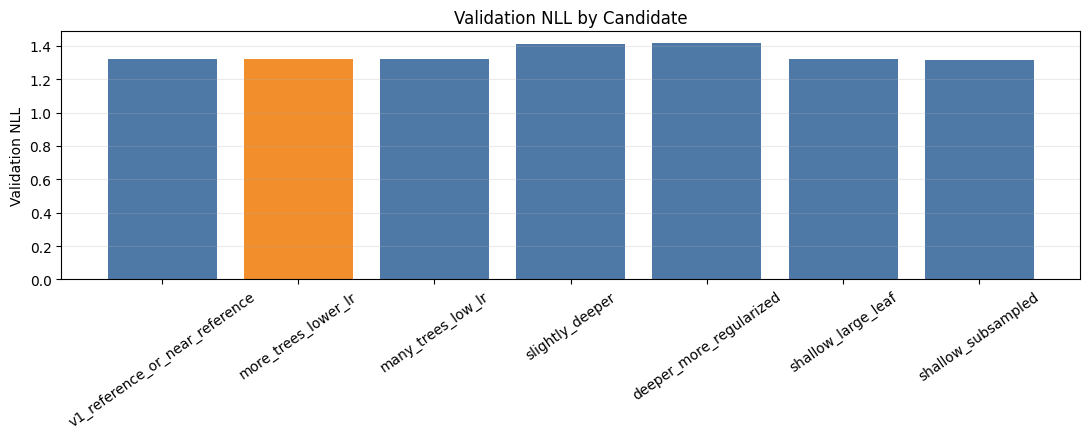

In [8]:
plot_df = latest_run.copy()
plot_df["is_selected"] = plot_df["candidate_name"].eq(selected_name)
plot_df = plot_df.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = np.where(plot_df["is_selected"], "#f28e2b", "#4e79a7")
ax.bar(plot_df["candidate_name"], plot_df["val_nll"], color=colors)
ax.set_title("Validation NLL by Candidate")
ax.set_ylabel("Validation NLL")
ax.tick_params(axis="x", rotation=35)
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


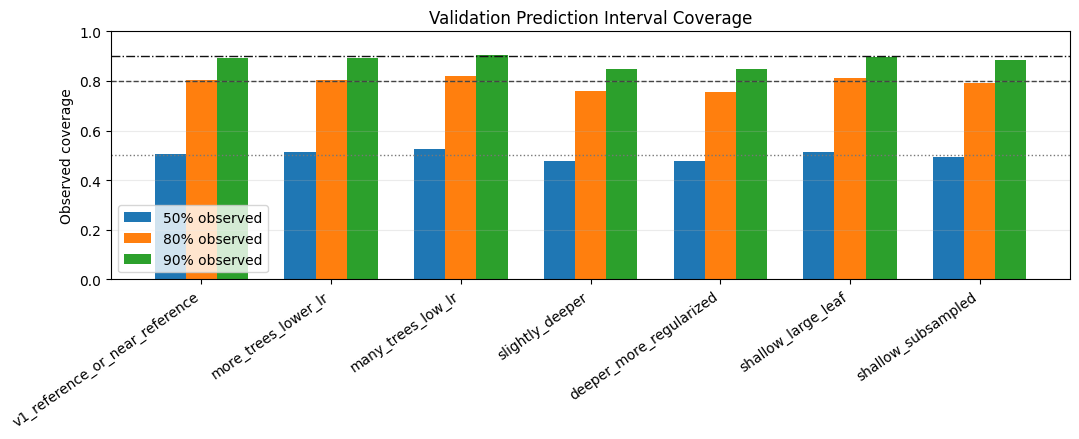

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(plot_df))
width = 0.24
for offset, level in [(-width, "50"), (0.0, "80"), (width, "90")]:
    ax.bar(x + offset, plot_df[f"val_{level}_coverage"], width=width, label=f"{level}% observed")
ax.axhline(0.5, color="#777777", linestyle=":", linewidth=1)
ax.axhline(0.8, color="#444444", linestyle="--", linewidth=1)
ax.axhline(0.9, color="#111111", linestyle="-.", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["candidate_name"], rotation=35, ha="right")
ax.set_ylim(0, 1)
ax.set_title("Validation Prediction Interval Coverage")
ax.set_ylabel("Observed coverage")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


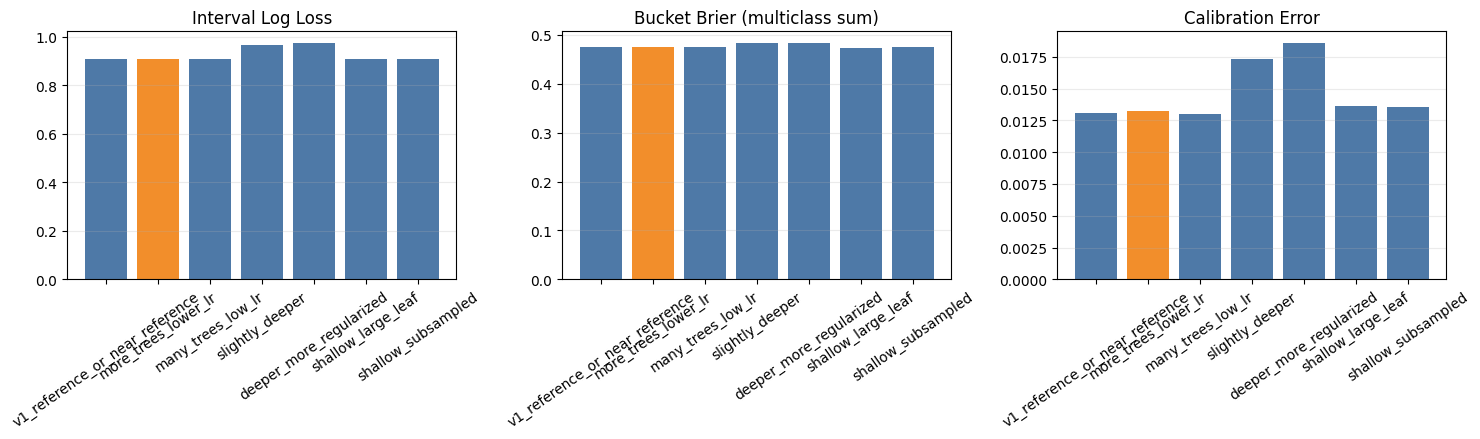

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, title in [
    (axes[0], "val_interval_log_loss", "Interval Log Loss"),
    (axes[1], "val_bucket_brier", "Bucket Brier (multiclass sum)"),
    (axes[2], "val_calibration_error", "Calibration Error"),
]:
    ax.bar(plot_df["candidate_name"], plot_df[metric], color=colors)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## PIT and Calibration Diagnostics

The tuning run saved diagnostics for the selected candidate. These are validation diagnostics only. They are useful for spotting distribution-shape and calibration issues, but they were not used as standalone selection criteria.


### PIT histogram

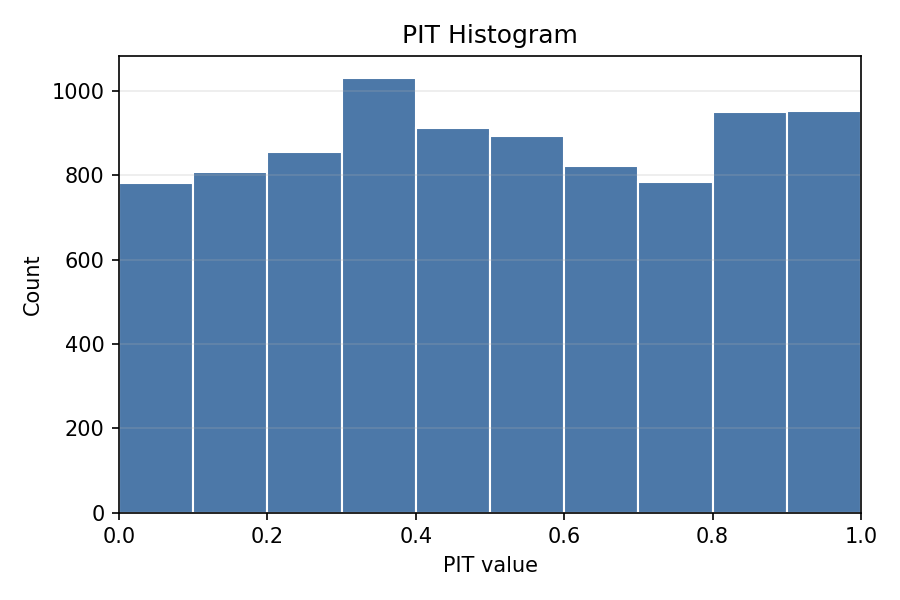

### Calibration curve

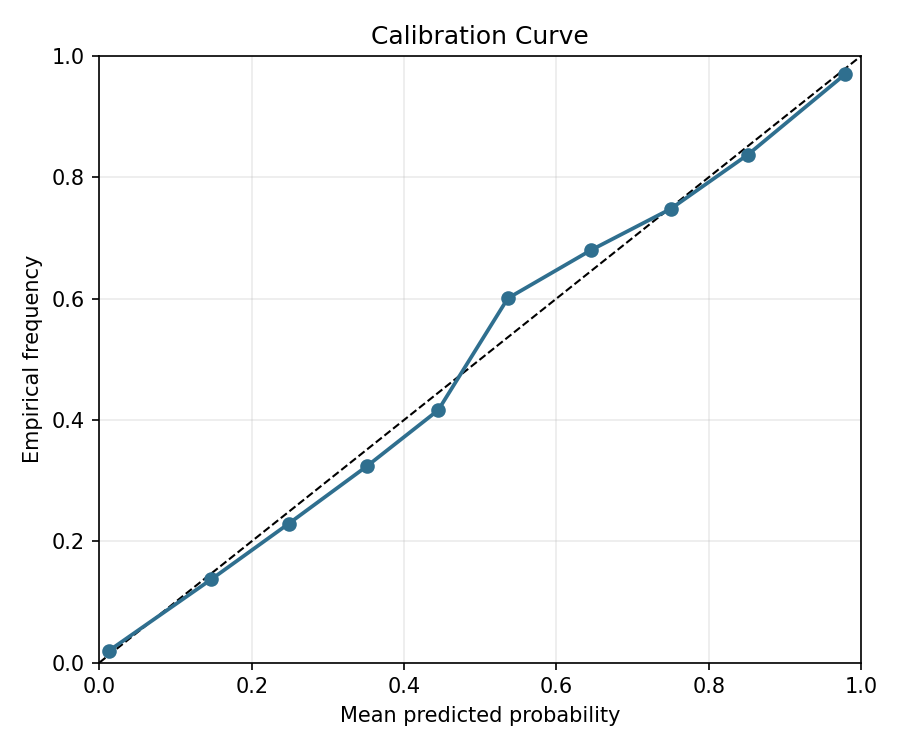

In [11]:
pit_path = FIGURES / "pit_histogram_ngboost_v2.png"
cal_path = FIGURES / "calibration_curve_ngboost_v2.png"

for label, path in [("PIT histogram", pit_path), ("Calibration curve", cal_path)]:
    display(Markdown(f"### {label}"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"Missing figure: `{path.relative_to(REPO_ROOT)}`"))


## Saved Output Files

These are the main artifacts produced by Day 16.


In [12]:
artifact_paths = [
    OUTPUTS / "ngboost_hyperparameter_search.csv",
    MODELS / "ngboost_best_v2.pkl",
    MODELS / "ngboost_best_v2_metadata.json",
    OUTPUTS / "best_ngboost_v2_notes.md",
    FIGURES / "pit_histogram_ngboost_v2.png",
    FIGURES / "calibration_curve_ngboost_v2.png",
    FIGURES / "ngboost_tuning_val_nll.png",
    FIGURES / "ngboost_tuning_coverage.png",
    FIGURES / "ngboost_tuning_interval_log_loss.png",
]

pd.DataFrame([
    {
        "artifact": str(path.relative_to(REPO_ROOT)),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    }
    for path in artifact_paths
])


,artifact,exists,size_bytes
0,outputs\ngboost_hyperparameter_search.csv,True,5433
1,models\ngboost_best_v2.pkl,True,930068
2,models\ngboost_best_v2_metadata.json,True,4223
3,outputs\best_ngboost_v2_notes.md,True,3383
4,outputs\figures\pit_histogram_ngboost_v2.png,True,18961
5,outputs\figures\calibration_curve_ngboost_v2.png,True,50172
6,outputs\figures\ngboost_tuning_val_nll.png,True,62668
7,outputs\figures\ngboost_tuning_coverage.png,True,76774
8,outputs\figures\ngboost_tuning_interval_log_lo...,True,64496


## How to Rerun

To rerun the tuning workflow from the repository root:

```bash
python -m src.train_ngboost --mode tune
```

The run appends to `outputs/ngboost_hyperparameter_search.csv` by default. Use `--overwrite-search-results` only when you intentionally want to replace the existing search table.


## Bottom Line

Day 16 produced a reproducible NGBoost v2 tuning workflow and selected `more_trees_lower_lr` as the saved model. The selected model slightly improved validation NLL versus the prior Normal reference while keeping 80% coverage very close to nominal.

The newest test period remains untouched and should be used only for a later final evaluation pass.
